Going to try with matplot lib

I used chatgpt to help me generate some of this initial code

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

Read in dataframes, and then make a list of dataframes so I can run through them all

In [21]:
df_2005 = pd.read_csv('DC-migration-2005.csv')
df_2009 = pd.read_csv('DC-migration-2009.csv')
df_2013 = pd.read_csv('DC-migration-2013.csv')
df_2017 = pd.read_csv('DC-migration-2017.csv')
df_2021 = pd.read_csv('DC-migration-2021.csv')



Drop the initial columns that were carried over from the indexes and messing up this data.

In [22]:
df_2005 = df_2005.drop(columns=["Unnamed: 0"])
df_2009 = df_2009.drop(columns=["Unnamed: 0"])
df_2013 = df_2013.drop(columns=["Unnamed: 0"])
df_2017 = df_2017.drop(columns=["Unnamed: 0"])
df_2021 = df_2021.drop(columns=["Unnamed: 0"])

In [23]:
dfs = [df_2005, df_2009, df_2013, df_2017, df_2021]

In [24]:
df_2005.tail()

,state,pop_migrated,MOE +/-,state_population,pop_migrated_upper,pop_migrated_lower,migrated_adjusted,migrated_adjusted_upper,migrated_adjusted_lower,moe_adjusted,winning_party,winner_percent_of_votes
43,Vermont,27,46,643077,73,-19,0.000042,0.000114,-0.000030,0.000072,DEMOCRAT,0.589375
44,Washington,443,354,7705281,797,89,0.000057,0.000103,0.000012,0.000046,DEMOCRAT,0.528211
45,West Virginia,389,376,1793716,765,13,0.000217,0.000426,0.000007,0.000210,REPUBLICAN,0.560707
46,Wisconsin,49,82,5893718,131,-33,0.000008,0.000022,-0.000006,0.000014,DEMOCRAT,0.496997
47,Wyoming,0,286,576851,286,-286,0.000000,0.000496,-0.000496,0.000496,REPUBLICAN,0.687396


Add in a state year column so in order to be able to loop through the dataframes


In [25]:
df_2005['year'] = 2005
df_2009['year'] = 2009
df_2013['year'] = 2013
df_2017['year'] = 2017
df_2021['year'] = 2021


Ok, multiplying by 100,000 to make the migrated_adjusted and moe_adjusted more readable 

In [26]:
for df in dfs:
    df['migrated_adjusted'] = df['migrated_adjusted'] * 100000
    df['moe_adjusted'] = df['moe_adjusted']* 100000

Some code to help me adjust the colors based on party, and strength of color to represent how red or blue the state 

In [27]:
df_2005

,state,pop_migrated,MOE +/-,state_population,pop_migrated_upper,pop_migrated_lower,migrated_adjusted,migrated_adjusted_upper,migrated_adjusted_lower,moe_adjusted,winning_party,winner_percent_of_votes,year
0,Alabama,0,286,5024279,286,-286,0.000000,0.000057,-5.692359e-05,5.692359,REPUBLICAN,0.624607,2005
1,Alaska,0,286,733391,286,-286,0.000000,0.000390,-3.899693e-04,38.996933,REPUBLICAN,0.610653,2005
2,Arizona,490,573,7151502,1063,-83,6.851708,0.000149,-1.160595e-05,8.012303,REPUBLICAN,0.548694,2005
3,Arkansas,0,286,3011524,286,-286,0.000000,0.000095,-9.496853e-05,9.496853,REPUBLICAN,0.543060,2005
4,California,2348,1010,39538223,3358,1338,5.938557,0.000085,3.384067e-05,2.554490,DEMOCRAT,0.543056,2005
5,Colorado,269,250,5773714,519,19,4.659046,0.000090,3.290776e-06,4.329969,REPUBLICAN,0.517111,2005
6,Connecticut,261,209,3605944,470,52,7.238049,0.000130,1.442063e-05,5.795986,DEMOCRAT,0.543137,2005
7,Delaware,357,346,989948,703,11,36.062500,0.000710,1.111169e-05,34.951331,DEMOCRAT,0.533468,2005
8,Florida,1103,461,21538187,1564,642,5.121137,0.000073,2.980752e-05,2.140384,REPUBLICAN,0.520975,2005
9,Georgia,319,209,10711908,528,110,2.977994,0.000049,1.026895e-05,1.951100,REPUBLICAN,0.579748,2005


In [28]:
# this converts into RGB numbers between 0 and 

def adjust_color(color, factor):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(np.clip(rgb * factor, 0, 1))

BASE_COLORS = {
    "REPUBLICAN": "#d62728",
    "DEMOCRAT": "#1f77b4"
}

Make sure all the values I need are numeric.

In [29]:
for df in dfs:

    df["migrated_adjusted"] = pd.to_numeric(df["migrated_adjusted"])
    df["moe_adjusted"] = pd.to_numeric(df["moe_adjusted"])
    df["winner_percent_of_votes"] = pd.to_numeric(df["winner_percent_of_votes"])


   

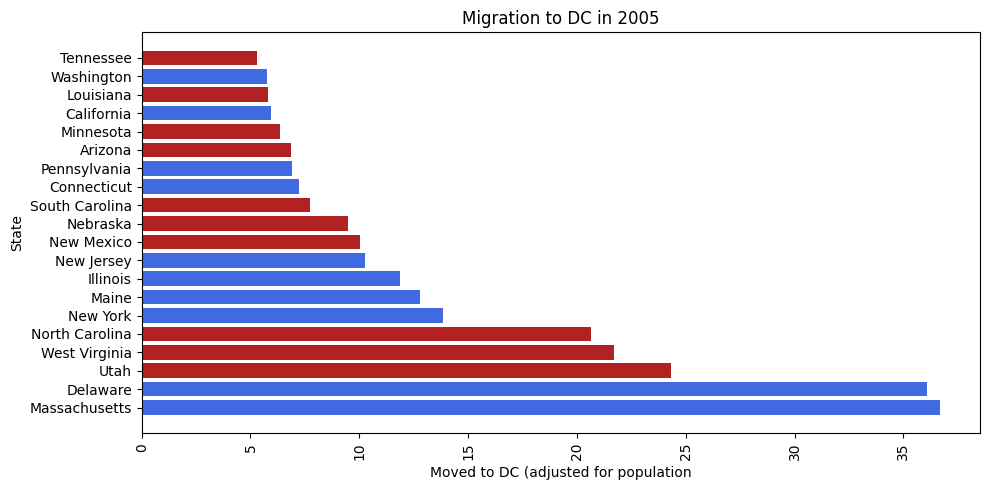

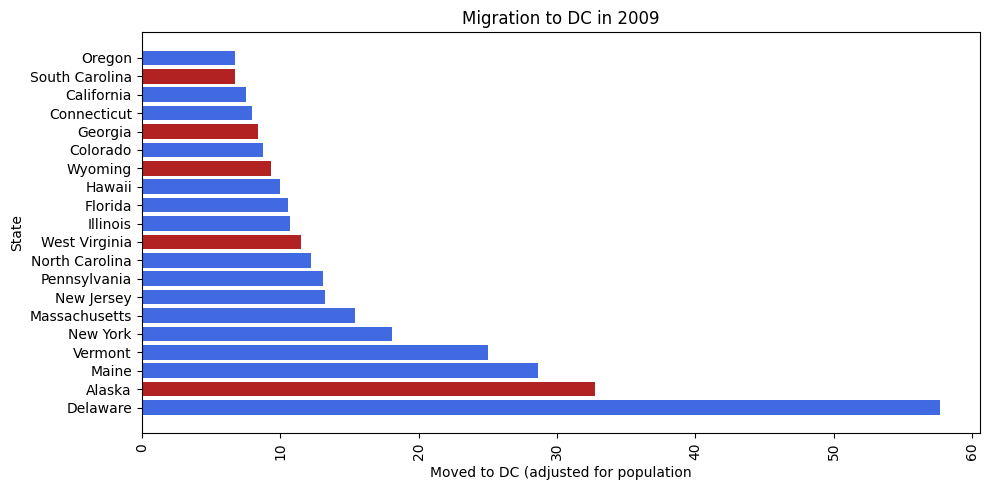

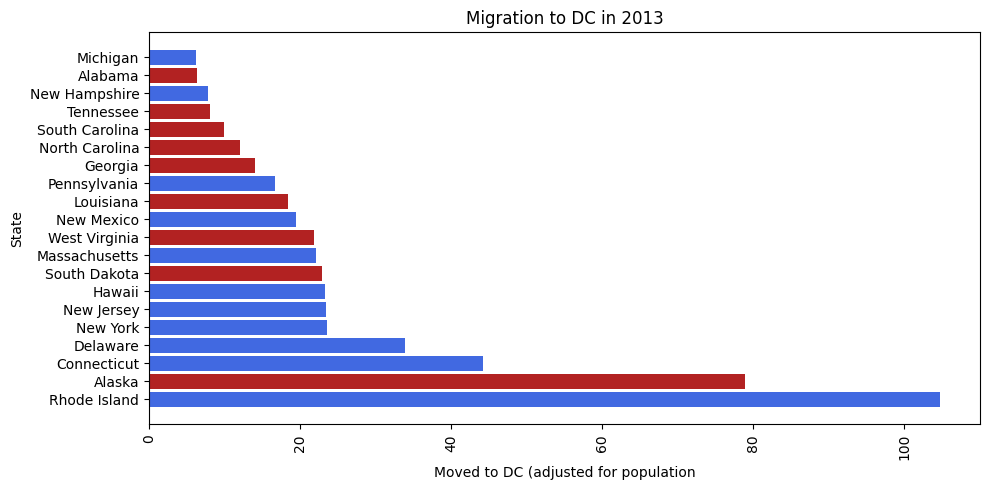

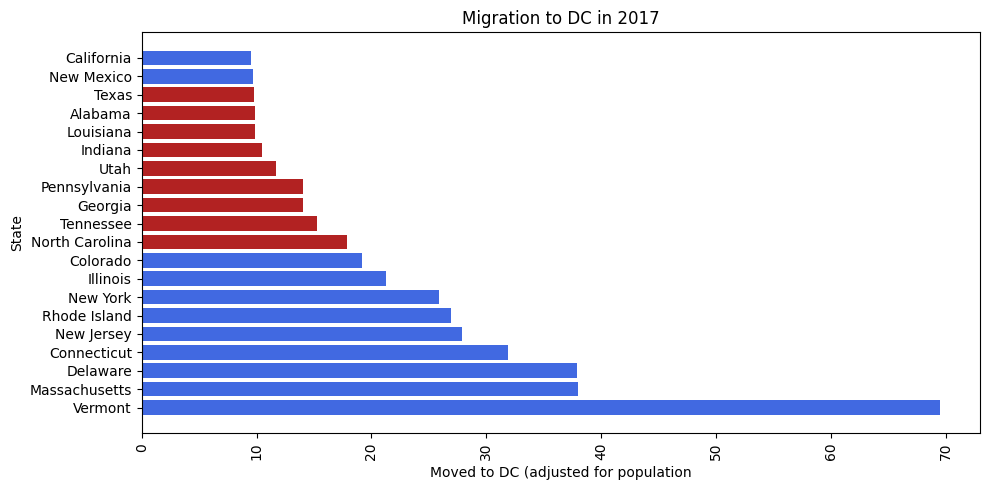

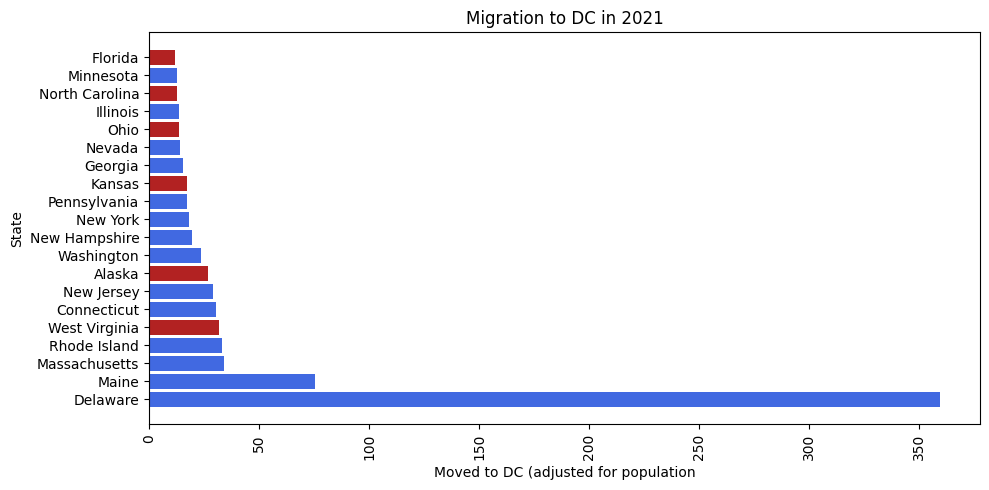

In [30]:
import matplotlib.pyplot as plt

for df in dfs:

    # Keep only the 8 states with the largest migration values
    df = df.nlargest(20, "migrated_adjusted")
    df.reset_index(drop=True, inplace=True)

    party_colors = {
    "REPUBLICAN": "firebrick",
    "DEMOCRAT": "royalblue"
    }

    colors = [party_colors.get(party, "gray") for party in df["winning_party"]]

    plt.figure(figsize=(10, 5))

    plt.barh(
        df["state"],                   # Labels on the x-axis
        df["migrated_adjusted"],       # Height of each bar
        # xerr=df["moe_adjusted"],       # Error bars (+/-)
        # capsize=3                      # Small horizontal caps on error bars
        color=colors

    )

    # Add labels and a title
    plt.title(f'Migration to DC in {df.loc[0, 'year']}')
    plt.xlabel("Moved to DC (adjusted for population")
    plt.ylabel("State")

    plt.xticks(rotation=90) # Rotate state names so they don't overlap

    plt.tight_layout()  # Automatically adjust spacing

    plt.show() # Display the chart


Graphing 2016 vs. 2017